****Artificial Intelligence and Machine Learning.Implementation of Convolutional Neural Network using Keras.****

***Worksheet - 5***

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import random
from sklearn.metrics import classification_report

***Setting paths of the datasets***

In [4]:
train_dir = r"C:\Users\riyat\Desktop\Ai_ML\week5\FruitinAmazon\train"
test_dir = r"C:\Users\riyat\Desktop\Ai_ML\week5\FruitinAmazon\test"

***Show Classes***


In [7]:
classes = os.listdir(train_dir)
print("Classes:", classes)
print("Total Classes:", len(classes))

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total Classes: 6


***Visualization***


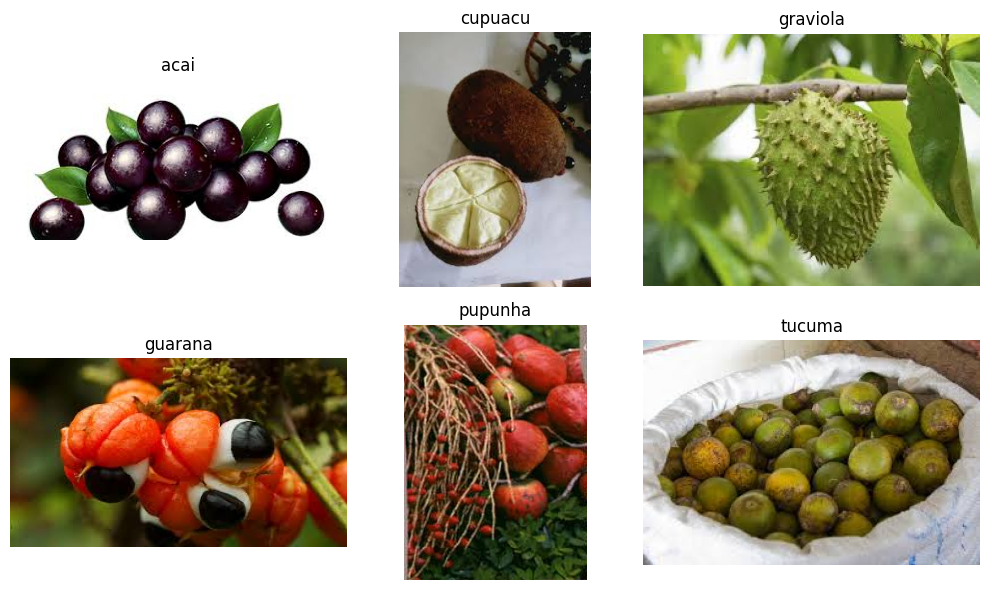

In [8]:
plt.figure(figsize=(10,6))

for i, class_name in enumerate(classes[:6]):
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

***Remove Corrupted Images***

In [9]:
corrupted = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


***Load Dataset***


In [11]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

In [12]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.


Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


***Normalize Data***

In [13]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

***Build CNN Model***

In [14]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(len(classes), activation='softmax')
])

C:\Users\riyat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


***Compile Model***

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

***TRAIN MODEL***

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0093

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.2222 - val_loss: 2.2942
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0077

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.3333 - val_loss: 2.2314
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.2778 - val_loss: 2.3629
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.2778 - val_loss: 2.4866
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.3333 - val_loss: 2.3774
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.4444 - val_loss: 2.3727
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.4444 - val_loss: 2.4253


***EVALUATE MODEL***

In [18]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6667 - loss: 0.9016
Test Accuracy: 0.6666666865348816


***SAVE & LOAD MODEL***

In [19]:
model.save("final_model.h5")

loaded_model = tf.keras.models.load_model("final_model.h5")

***PREDICTIONS + CLASSIFICATION REPORT***

In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.50      1.00      0.67         5
           2       1.00      1.00      1.00         5
           3       1.00      0.60      0.75         5
           4       0.67      0.40      0.50         5
           5       0.40      0.40      0.40         5

    accuracy                           0.67        30
   macro avg       0.72      0.67      0.66        30
weighted avg       0.72      0.67      0.66        30



***VISUALIZATION (GRAPHS)***

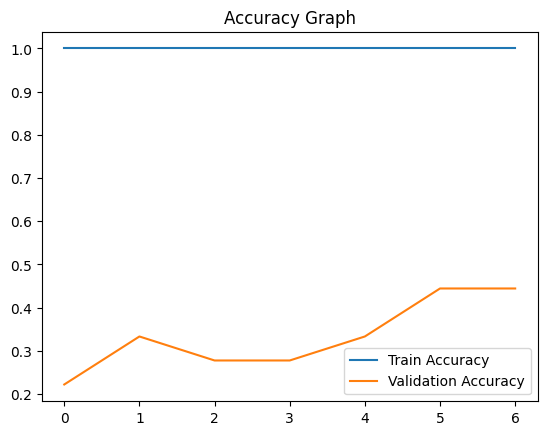

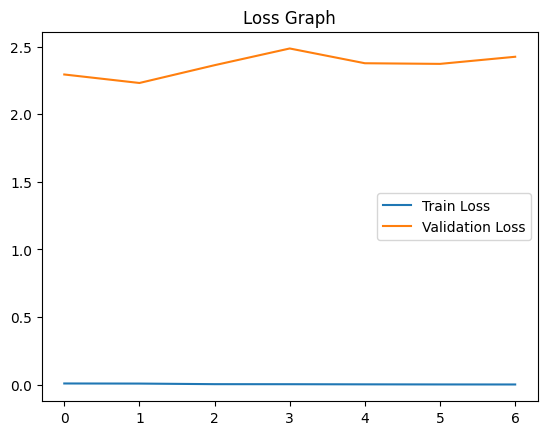

In [21]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()